# Diurnal Slot Semivariogram — Short-Lag Spatial Variability by Time-of-Day

**Goal**: Does short-lag spatial roughness (γ at lag 1-3) follow a diurnal cycle?

**Data**: Pooled across years/months; slot h0–h7 = 8 GEMS observation windows per day.

In [2]:
import sys, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config

# ── Load pkl ──────────────────────────────────────────────────────────────────
#PKL_PATH = Path(config.mac_save_computed_semi_path) / "diurnal_slot_sem_22_23_24_25_m07.pkl"
PKL_PATH = Path(config.mac_save_computed_semi_path) / "diurnal_slot_sem_22_23_24_25_m04_m05_m06_m07_m08_m09.pkl"
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

lags_lat = [d[0] for d in data["lags_lat"]]   # [0.044, 0.088, 0.132]
lags_lon = [d[1] for d in data["lags_lon"]]   # [0.063, 0.126, 0.189]
lat_sem  = data["lat"]    # {slot: [γ_lag1, γ_lag2, γ_lag3]}
lon_sem  = data["lon"]
meta     = data["meta"]

N_SLOTS  = 8
print(f"Years : {meta['years']}")
print(f"Months: {meta['months']}")
print(f"n_days per slot (lat): {meta['n_days_per_slot_lat']}")

# ── Print table ───────────────────────────────────────────────────────────────
for direction, sem, lags in [("LAT", lat_sem, lags_lat), ("LON", lon_sem, lags_lon)]:
    print(f"\n{'='*60}")
    print(f"Direction: {direction}")
    col_w = 14
    hdr = f"{'slot':>5} | " + " | ".join(f"step{j+1}(Δ={lags[j]:.3f}°)".center(col_w) for j in range(len(lags)))
    print(hdr)
    print("-" * len(hdr))
    for h in range(N_SLOTS):
        row = " | ".join(f"{sem[h][j]:>{col_w}.4f}" for j in range(len(lags)))
        print(f"  h{h}   | {row}")


Years : ['2022', '2023', '2024', '2025']
Months: [4, 5, 6, 7, 8, 9]
n_days per slot (lat): {0: 726, 1: 726, 2: 726, 3: 726, 4: 726, 5: 726, 6: 726, 7: 726}

Direction: LAT
 slot | step1(Δ=0.044°) | step2(Δ=0.088°) | step3(Δ=0.132°)
-----------------------------------------------------------
  h0   |         3.9022 |         5.3490 |         6.2480
  h1   |         4.1992 |         5.9255 |         6.9665
  h2   |         4.1620 |         6.1265 |         7.3234
  h3   |         4.1183 |         6.1973 |         7.4883
  h4   |         4.3781 |         6.6299 |         8.0414
  h5   |         4.1741 |         6.0976 |         7.2856
  h6   |         3.4840 |         4.9859 |         5.9214
  h7   |         3.0770 |         4.2544 |         4.9679

Direction: LON
 slot | step1(Δ=0.063°) | step2(Δ=0.126°) | step3(Δ=0.189°)
-----------------------------------------------------------
  h0   |         3.9926 |         5.1914 |         6.0186
  h1   |         4.3310 |         5.8006 |        

## Main Plot — LAT & LON semivariograms by time slot

Blue spectrum: h0 (lightest) → h7 (darkest). Distance 0 left empty.

/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_25254/3444244636.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


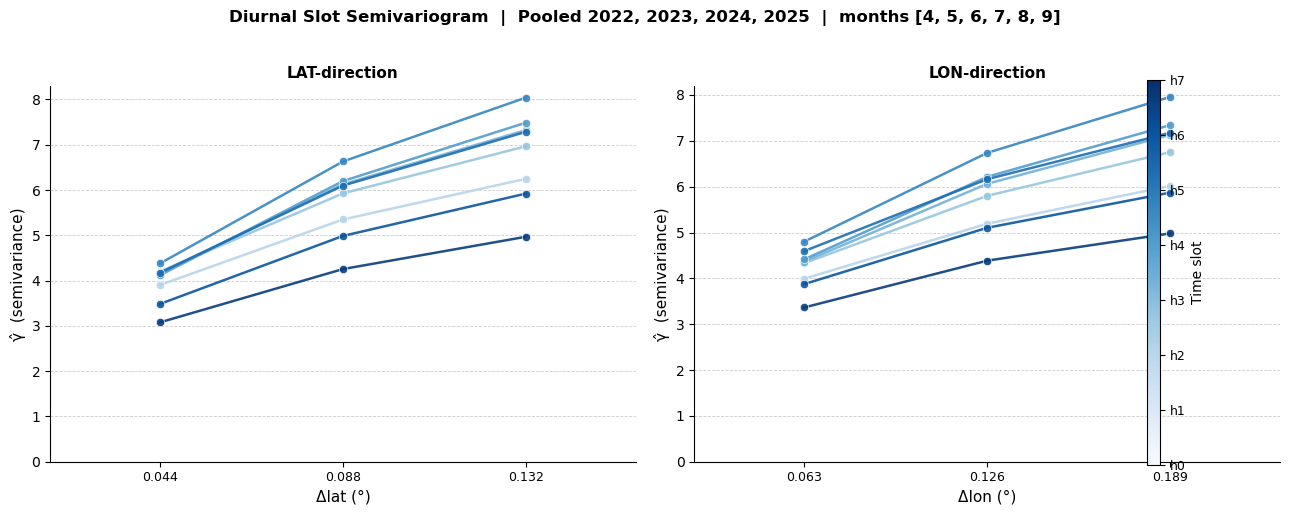

Saved → /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/loss_landscape/diurnal_slot_sem_2022_2023_2024_2025_m4_5_6_7_8_9.png


In [3]:
# ── Color palette: Blues spectrum h0(light) → h7(dark) ──────────────────────
blues = cm.Blues(np.linspace(0.30, 0.95, N_SLOTS))

SLOT_LABELS = [f"h{h}" for h in range(N_SLOTS)]
MARKER      = "o"
MS          = 6       # marker size
LW          = 1.8     # line width
ALPHA_LINE  = 0.90

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle(
    "Diurnal Slot Semivariogram  |  "
    f"Pooled {', '.join(meta['years'])}  |  "
    f"months {meta['months']}",
    fontsize=12, fontweight="bold", y=1.02
)

for ax, lags, sem, direction, xlabel in [
    (axes[0], lags_lat, lat_sem, "LAT",  "Δlat (°)"),
    (axes[1], lags_lon, lon_sem, "LON",  "Δlon (°)"),
]:
    for h in range(N_SLOTS):
        y = sem[h]
        ax.plot(lags, y,
                color=blues[h], lw=LW, alpha=ALPHA_LINE,
                marker=MARKER, ms=MS, markerfacecolor=blues[h],
                markeredgecolor="white", markeredgewidth=0.5,
                label=SLOT_LABELS[h], zorder=3)

    # ── Axes styling ──────────────────────────────────────────────────────────
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("γ̂  (semivariance)", fontsize=11)
    ax.set_title(f"{direction}-direction", fontsize=11, fontweight="bold")

    # x-axis starts just before lag1 (leave distance-0 empty)
    x_pad = lags[0] * 0.6
    ax.set_xlim(lags[0] - x_pad, lags[-1] + x_pad)

    # Clean tick marks at data lags only
    ax.set_xticks(lags)
    ax.set_xticklabels([f"{d:.3f}" for d in lags], fontsize=9)

    # Grid: subtle horizontal only
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.4, color="gray")
    ax.set_axisbelow(True)

    # Remove top / right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # y starts at 0
    ax.set_ylim(bottom=0)

# ── Shared colorbar-style legend (Blues strip h0→h7) ─────────────────────────
norm  = mcolors.Normalize(vmin=0, vmax=N_SLOTS - 1)
sm    = cm.ScalarMappable(cmap=cm.Blues, norm=norm)
sm.set_array([])
cbar  = fig.colorbar(sm, ax=axes, orientation="vertical",
                     fraction=0.018, pad=0.02, aspect=30)
cbar.set_ticks(np.arange(N_SLOTS))
cbar.set_ticklabels([f"h{h}" for h in range(N_SLOTS)], fontsize=9)
cbar.set_label("Time slot", fontsize=10)

plt.tight_layout()

OUT = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/loss_landscape")
OUT.mkdir(parents=True, exist_ok=True)
save_name = f"diurnal_slot_sem_{'_'.join(meta['years'])}_m{'_'.join(str(m) for m in meta['months'])}.png"
plt.savefig(OUT / save_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT / save_name}")


## Diurnal Pattern Summary — γ(lag1) by slot

Shows the diurnal cycle of short-range variability most clearly.

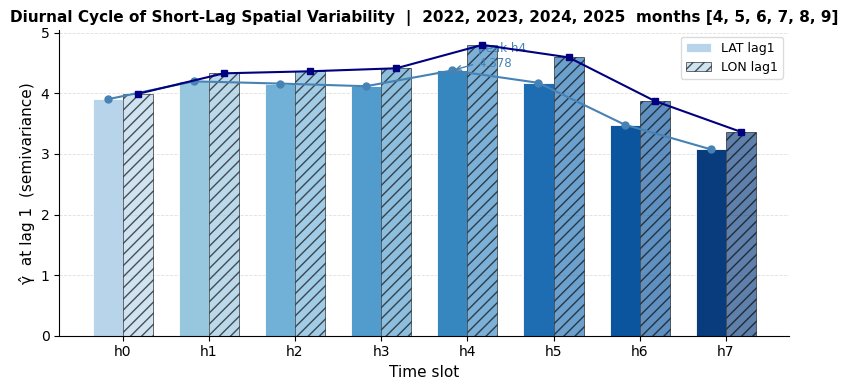

In [4]:
# ── γ(lag1) vs time slot — diurnal cycle summary ────────────────────────────
lat_lag1 = [lat_sem[h][0] for h in range(N_SLOTS)]
lon_lag1 = [lon_sem[h][0] for h in range(N_SLOTS)]

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(N_SLOTS)
w = 0.35
bars_lat = ax.bar(x - w/2, lat_lag1, width=w,
                  color=[blues[h] for h in range(N_SLOTS)],
                  edgecolor="white", linewidth=0.6, label="LAT lag1")
bars_lon = ax.bar(x + w/2, lon_lag1, width=w,
                  color=[blues[h] for h in range(N_SLOTS)],
                  edgecolor="black", linewidth=0.6, alpha=0.65, label="LON lag1",
                  hatch="///")

# Line overlay
ax.plot(x - w/2, lat_lag1, "o-", color="steelblue",  lw=1.5, ms=5, zorder=5)
ax.plot(x + w/2, lon_lag1, "s-", color="navy",       lw=1.5, ms=5, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([f"h{h}" for h in range(N_SLOTS)], fontsize=10)
ax.set_xlabel("Time slot", fontsize=11)
ax.set_ylabel("γ̂  at lag 1  (semivariance)", fontsize=11)
ax.set_title(
    f"Diurnal Cycle of Short-Lag Spatial Variability  |  "
    f"{', '.join(meta['years'])}  months {meta['months']}",
    fontsize=11, fontweight="bold"
)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate peak
peak_h = int(np.argmax(lat_lag1))
ax.annotate(f"peak h{peak_h}\n{lat_lag1[peak_h]:.3f}",
            xy=(peak_h - w/2, lat_lag1[peak_h]),
            xytext=(peak_h - w/2 + 0.3, lat_lag1[peak_h] + 0.05),
            fontsize=8.5, color="steelblue",
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.0))

ax.legend(fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.savefig(OUT / f"diurnal_lag1_summary_{'_'.join(meta['years'])}.png",
            dpi=150, bbox_inches="tight")
plt.show()


## Run 6-month version

```bash
cd /Users/joonwonlee/Documents/GEMS_TCO-1/GEMS_TCO_EDA/semivariograms/mac_compute_empirical_sem_and_cv
python diurnal_slot_semivariogram_040626.py --years "2022,2023,2024,2025" --months "4,5,6,7,8,9"
```

Then update `PKL_PATH` above to `diurnal_slot_sem_22_23_24_25_m04_m05_m06_m07_m08_m09.pkl`.